# Ejercicio 3: Inspección visual de un producto

**Curso:** Inteligencia Artificial I - IS484  
**Práctica:** Práctica Calificada 001  
**Estudiante:** Alexis Huamani Rivera

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **P - Medida de desempeño** | Clasificar correctamente los productos según la presencia de defectos, reduciendo la aprobación de productos defectuosos y evitando rechazos innecesarios de productos aptos. |
| **E - Entorno** | Línea de producción donde cada producto es inspeccionado mediante una cámara antes de continuar al siguiente proceso. |
| **A - Actuadores** | Aprobar el producto, enviarlo a revisión manual o rechazarlo. |
| **S - Sensores / Percepciones** | Imagen de 5×5 píxeles capturada por la cámara, representada como una matriz NumPy con valores 0 y 1. |

**Objetivo:** detectar la presencia de defectos visuales y seleccionar una acción apropiada según la cantidad de píxeles defectuosos encontrados.

**Tipo de agente:** agente reactivo simple basado en reglas.

**Racionalidad:** el agente decide únicamente a partir de la imagen actual del producto. Su comportamiento es racional dentro del modelo simplificado siempre que la cámara represente correctamente los defectos mediante valores 0 y 1.

### Justificación de las reglas

Las reglas consideran que un producto sin píxeles defectuosos puede continuar normalmente en la línea de producción. Cuando aparecen pocos defectos, resulta razonable solicitar una revisión manual antes de tomar una decisión definitiva. Si la cantidad de píxeles defectuosos supera el límite establecido, el producto se rechaza para evitar que una pieza con defectos visibles continúe en el proceso.

#### Reglas de decisión

| Cantidad de píxeles defectuosos | Acción |
|---|---|
| 0 defectos | **Aprobar** |
| De 1 a 3 defectos | **Revisión manual** |
| Más de 3 defectos | **Rechazar** |

In [ ]:
import numpy as np


def agente_inspeccion(imagen):
    """
    Agente reactivo simple 

    Percepción:
    - imagen: matriz NumPy de 5x5.
      0 = píxel normal
      1 = píxel defectuoso

    Acciones:
    - aprobar
    - revisión manual
    - rechazar
    """

    defectos = np.sum(imagen == 1)

    if defectos == 0:
        return (
            "aprobar",
            "no se detectaron píxeles defectuosos"
        )

    elif defectos <= 3:
        return (
            "revisión manual",
            f"se detectaron {defectos} píxeles defectuosos"
        )

    else:
        return (
            "rechazar",
            f"se detectaron {defectos} píxeles defectuosos"
        )

### Simulación y pruebas

Se prueban distintas imágenes de 5×5 para verificar las tres decisiones posibles del agente. Se incluyen un producto sin defectos, casos de revisión manual, el límite exacto de 3 defectos y un producto que debe ser rechazado.

In [3]:
imagen_1 = np.zeros((5, 5), dtype=int)

imagen_2 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

imagen_3 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]
])

imagen_4 = np.array([
    [1, 0, 0, 0, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0]
])

imagen_5 = np.array([
    [1, 0, 1, 0, 1],
    [0, 1, 0, 1, 0],
    [1, 0, 1, 0, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

imagenes_prueba = [
    ("Producto sin defectos", imagen_1),
    ("Producto con 1 defecto", imagen_2),
    ("Producto con 3 defectos - caso límite", imagen_3),
    ("Producto con 5 defectos", imagen_4),
    ("Producto con 8 defectos", imagen_5)
]

for nombre, imagen in imagenes_prueba:
    accion, motivo = agente_inspeccion(imagen)

    print(nombre)
    print(imagen)
    print("Decisión:", accion)
    print("Motivo:", motivo)
    print("-" * 50)

Producto sin defectos
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Decisión: aprobar
Motivo: no se detectaron píxeles defectuosos
--------------------------------------------------
Producto con 1 defecto
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Decisión: revisión manual
Motivo: se detectaron 1 píxeles defectuosos
--------------------------------------------------
Producto con 3 defectos - caso límite
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 1 0 0 0]]
Decisión: revisión manual
Motivo: se detectaron 3 píxeles defectuosos
--------------------------------------------------
Producto con 5 defectos
[[1 0 0 0 1]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]]
Decisión: rechazar
Motivo: se detectaron 5 píxeles defectuosos
--------------------------------------------------
Producto con 8 defectos
[[1 0 1 0 1]
 [0 1 0 1 0]
 [1 0 1 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Decisión: rechazar
Motivo: se detectaron 8 píxeles defectuosos
------

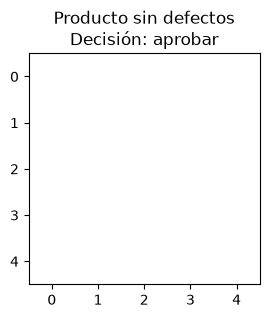

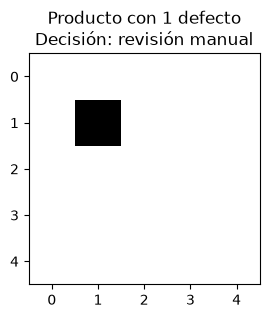

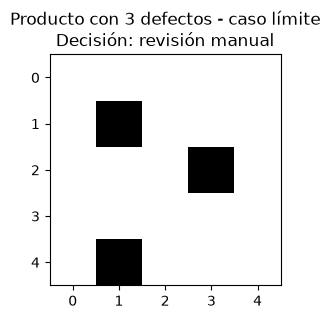

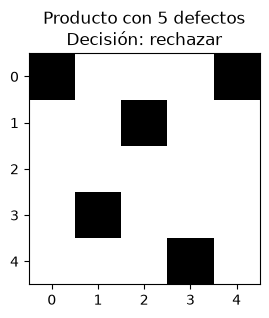

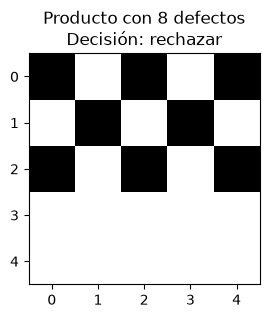

In [4]:
import matplotlib.pyplot as plt

for nombre, imagen in imagenes_prueba:
    accion, _ = agente_inspeccion(imagen)

    plt.figure(figsize=(3, 3))
    plt.imshow(imagen, cmap="gray_r", vmin=0, vmax=1)
    plt.title(f"{nombre}\nDecisión: {accion}")
    plt.xticks(range(5))
    plt.yticks(range(5))
    plt.grid(False)
    plt.show()